# Cooldown 5
Looking at implanted SiC sites

### Drivers, packages, etc.

In [447]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import math
import scipy as sp
import datetime
import scipy.fft
import scipy.optimize as sp
import os
import time
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
import qil_Visa.visa as visa
import pyvisa
from IPython.display import clear_output,display
import pyvisa
import TimeTagger

# Import functions from longterm sweeps!!
sys.path.append(r"C:\Users\Mario\Documents\GitHub\longterm_sweeps")
import drivers.spectroscopyHelpers as sh
import drivers.pulse_sequence as beeps
import drivers.proHelpers as proHelp
from drivers.dlccontrol import dlccontrol as ctrl
import drivers3.laserHelpers as lhzz
import drivers.plottingHelpers as plhp
import drivers.plottingFunctions as plf

# Import functions from local directory
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")
import qil_helpers.Ben.LaserWrappers as ben
import qil_helpers.Fergus.magnet_helpers as ferg
import qil_helpers.Angela.sweeping as swp
import qil_helpers.Angela.switching as swtch
import qil_helpers.Angela.snspd as snshp
import qil_helpers.Angela.experimentHelpers as exhp
from unit_dmm.ut61eplus.ut61eplus import UT61EPLUS

### Useful/miscellaneous functions

In [2]:
# Various other functions
def getHistDataWrapped(hist, intTime=0.1):
    ps = 1e12                               # ps/s
    hist.startFor(intTime*ps, clear=True)   # run the histogram measurment for 5 seconds then get data. Clear removes old data before starting the measurement
    hist.waitUntilFinished()                # pause execution of python code until the measurement finished flag is true 
    data = hist.getData()                   # get data, of course 
    times = hist.getIndex()/ps              # time [s]
    return data, times

def test_histogram(intTime = 1, plot = 'lin'):
    data, times = getHistDataWrapped(intTime)
    laserFrequency = np.round(exhp.get_laser_frequency(wm, 20),6)
    if plot =='log':
        plt.semilogy(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    else:    
        plt.plot(times*1e3, data, label= "Total Counts: " + str(sum(data)))              
    plt.xlabel("Time (ms)")
    plt.title(str(laserFrequency) + ' THz, '+ str(intTime)+' s integration')              
    plt.legend()
#----------------------------------------------------------------------------#
def adjust_by_db(inputValue, gain):
    outputValue = inputValue * (10** (gain/10))

    return outputValue 
#----------------------------------------------------------------------------#
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)
#----------------------------------------------------------------------------#
def setfontsize(size, ax):
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(size)
    return
#----------------------------------------------------------------------------#
def measure_dmm(dmm):
    meas = dmm.takeMeasurement()
    if not meas.overload:
        measurement  = meas.display
    else:
        measurement = -1
        print(f'WARNING: Check your sh*t')
    return measurement
#----------------------------------------------------------------------------#
def do_efficiency_measurement(detectorOut, unit, hist, wm, inputPower, countTimeRatio, voltageRange, voltageInt, runID, savePlot):
    ''' 
    Takes SNSPD efficiency measurement over bias current/voltage.

    ARGUMENTS (ignoring instruments)
    inputPower: optical power after attenuation
    countTimeRatio: ON/OFF time ratio for SNSPD trigger. depends on switching status
    voltageRange: [2x1 ARRAY] bias voltage range

    RETURNS 
    (voltages, biasCurrents, totalCounts, efficiencies), where length of each array depends on voltageRange and voltageInt
    '''

    intTime = 2
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    countsPerSecond = np.zeros_like(voltages)
    efficiencies = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    frequency = exhp.get_laser_frequency(wm, 1)*1e12 # Hz
    h = 6.62607015e-34
    ePerPhoton = h*frequency
    inputCounts = inputPower / ePerPhoton
    
    def normaliseCounts(measuredCounts, intTime, countTimeRatio):
        countsPerSecond =  measuredCounts / (intTime * countTimeRatio) 
        return countsPerSecond

    def countsToEffs(measuredCounts, intTime, countTimeRatio):
        countsPerSecond = normaliseCounts(measuredCounts, intTime, countTimeRatio) 
        efficiency = 100 * countsPerSecond / inputCounts 
        return efficiency
    
    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 1s before taking measurement
        biasCurrents[i] = exhp.get_detector_current(dmm) * 1e6 # store as uA
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s
        countsPerSecond[i] = normaliseCounts(totalCounts[i], intTime, countTimeRatio) # counts per second
        efficiencies[i] = countsToEffs(sum(data), intTime, countTimeRatio)

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, efficiencies)
        sec = ax.twinx()
        sec.plot(biasCurrents, countsPerSecond, alpha = 0)

        ax.set_title("Efficiency vs V$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
        ax.set_xlabel("- SNSPD Bias Voltage (V))")
        sec.set_ylabel("Counts")
        ax.set_ylabel('Efficiency (%)')
        # ax.set_ylim(0, 40)

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector once sweep is complete
    exhp.reset_detector(detectorOut, 0)
    measure_dmm(unit)

    # final plot
    fig, ax = plt.subplots()
    fig.set_size_inches(plhp.cm2inch(20, 15))
    ax.plot(voltages, efficiencies)
    sec = ax.twinx()
    sec.plot(voltages, countsPerSecond, alpha = 0)
    sec.set_ylabel(fr'Count Rate (s$^{-1}$)')
    ax2 = ax.twiny()
    ax2.set_xlabel('Voltage (V)')
    ax2.plot(biasCurrents, efficiencies, alpha = 0)
    ax.set_title("Efficiency vs i$_{{bias}}$, " + str(intTime) + "s Integration, " + str(round(inputCounts)) + " Photons/s Exc")
    sec.set_ylabel(f"Total Counts in {intTime} s")
    ax.set_ylabel('Efficiency (%)')
    # ax.set_ylim(0, 40)
    ax.set_xlabel("SNSPD Bias Current ($\mu$A)")

    display(plt.gca())
    clear_output(wait = True)
    plt.tight_layout()
    if savePlot == True:
        dateString = time.strftime('%Y-%m-%d')
        plotPath = fr'plots/{dateString}'
        os.makedirs(plotPath, exist_ok=True)
        plt.savefig(fr'{plotPath}/efficiency{runID}.jpg')
    plt.show()
    
    return (voltages, biasCurrents, totalCounts, efficiencies)

def do_dark_measurement(detectorOut, dmm, hist, voltageRange, voltageInt, intTime, countTimeRatio, runID, save = False):
    '''
    Basically same measurement as above. But make sure the laser is shuttered/there is no input.
    '''
    dwell = 1
    voltages = swp.sweep_points(voltageRange[0], voltageRange[1], voltageInt)
    biasCurrents = np.zeros_like(voltages)
    totalCounts = np.zeros_like(voltages)
    
    # expDuration = datetime.timedelta(seconds = len(voltages) * (intTime + dwell))
    # print(fr'Experiment time ~ {str(expDuration)}')

    for i, voltage in enumerate(tqdm(voltages)):
        exhp.reset_detector(detectorOut, voltage) # set bias
        time.sleep(dwell) # wait for 0.5s before taking measurement
        if dmm == unit:
            bias = measure_dmm(unit) # store as uA
        else:
            bias = exhp.get_detector_current(dmm)
        biasCurrents[i] = bias
        
        data, times = exhp.getHistDataWrapped(hist, intTime)
        totalCounts[i] = sum(data) # total counts over intTime = 2s

        fig, ax = plt.subplots()
        fig.set_size_inches(plhp.cm2inch(20, 12))
        ax.plot(voltages, totalCounts / (countTimeRatio * intTime), c = 'tab:blue')

        ax.set_title(fr"Dark Counts vs V$_{{bias}}$, " + str(intTime) + "s Integration")
        # ax.set_xlabel(r"SNSPD Bias Current ($\mu$A)")
        ax.set_xlabel(r"SNSPD Bias Voltage (V)")
        ax.set_ylabel(r"Dark Count Rate (s$^{-1}$)")

        display(plt.gca())
        clear_output(wait = True)
        plt.show()
    
    # reset detector after measurement
    exhp.reset_detector(detectorOut, 0)
    time.sleep(1)
    if dmm == unit:
        measure_dmm(unit) # store as uA
    else:
        exhp.get_detector_current(dmm)    
    return (voltages, biasCurrents, totalCounts)

### Instruments

In [5]:
### Toptica Laser
from toptica.lasersdk.dlcpro.v2_2_0 import DLCpro, NetworkConnection  
laserIP = '10.196.50.22'
timTam = ben.laser_TT(laserIP, 0.1)

### Wavemeter
from qil_WS6wavemeter import TCP_Wavemeter
try:
    wm = TCP_Wavemeter.cWS6WavemeterClient(host='qil-wario')
    print("Wavemeter frequency: ", wm.readFrequency())
except KeyError:
    print("Key error returned - wavemeter probably not seeing enough light.")

### Stahl power supply
from qcodes.instrument_drivers.rigol import DP832
from qcodes.instrument_drivers.stahl import Stahl
stahl = Stahl("stahl-9", "ASRL4")       
detectorOut = stahl.channel8            

### Moku AWG
import moku

### For the Moku Pro
from moku.instruments import ArbitraryWaveformGenerator
mokuIP = '10.196.50.45' # Sydnet6 IP for Moku Pro
awg = ArbitraryWaveformGenerator(mokuIP, force_connect=True, persist_state=True, read_timeout=30)

### For Bluey
import json 
import requests

# ### Keithley DMM
# import qcodes.instrument_drivers.tektronix.Keithley_6500 as dmm6500
# dmm = dmm6500.Keithley_6500('dmm','TCPIP::10.196.50.27::INSTR')

### UNI-T dmm
unit = UT61EPLUS()

### Rigol oscilloscope 
from qil_Rigol.rigol import cRigol 
scope = cRigol('10.196.50.21') # IP address of Rigol MSO5104 on the gantry is: 10.196.50.21. verify connection here.

Importing Functions
Wavemeter frequency:  198.92486572265625
Connected to: Stahl HV (serial:177, firmware:None) in 0.03s


c:\Users\Mario\.conda\envs\qcodes_env\lib\site-packages\qcodes\instrument\instrument_base.py:642: UserWarning: Changed stahl-9 to stahl_9 for instrument identifier
  warnings.warn(f"Changed {name} to {new_name} for instrument identifier")


Connected to RIGOL TECHNOLOGIES,MSO5104,MS5A234906950,00.01.03.00.03
 succesfully 


In [588]:
### American magnetics power supply
from qcodes.instrument_drivers.american_magnetics.AMI430_visa import AMI430
iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis
iz.add_parameter("get_vs", 
                 get_cmd ='VOLT:SUPP?', 
                 get_parser = float)
iz.add_parameter("get_cs", 
                 get_cmd ='CURR:SUPP?', 
                 get_parser = float) 

C:\Users\Mario\AppData\Local\Temp\ipykernel_16784\4276116187.py:3: QCoDeSDeprecationWarning: Use qcodes.instrument_drivers.american_magnetics.AMIModel430 instead.
  iz = AMI430('z', address = "TCPIP0::10.196.50.17::7180::SOCKET") # connnect to z-axis


Connected to: AMERICAN MAGNETICS INC. 430 (serial:430-20-123, firmware:3.12) in 1.18s


<qcodes.parameters.parameter.Parameter: get_cs at 2204791110480>

In [451]:
### Attocube
import qil_attocube
amc = qil_attocube.Device('10.196.50.26')
amc.connect()
axis = 0 # Corresponds to axis 1 on the AMC300 controller

KeyboardInterrupt: 

### Free Instruments

In [456]:
swtch.all_on(awg)

In [ ]:
all_off(awg, plotting = False)

In [582]:
exhp.reset_detector(detectorOut, 0)

0

In [411]:
exhp.reset_detector(detectorOut, -0.85)
# time.sleep(1)
# measure_dmm(unit)

-0.85

In [611]:
import TimeTagger
tt = TimeTagger.createTimeTagger()
TimeTagger.freeTimeTagger(tt)
tt

<TimeTagger.TimeTagger; proxy of None >

In [ ]:
stahl.close()

In [587]:
iz.close()

In [22]:
lhzz.turn_laser_off(laserIP)

Laser is off


In [24]:
lhzz.turn_laser_on(laserIP)

Laser is on


# Dark Counts
check how bad sporadic noise is

In [5]:
darkID = 2

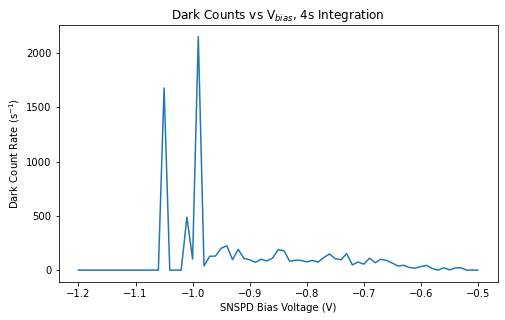

100%|██████████| 71/71 [06:49<00:00,  5.77s/it]


In [7]:
print(fr'Run {darkID}')

# Time tagger
tt = TimeTagger.createTimeTagger()
ps = 1e12 # [ps/s] - picoseconds per second. As usual I try to frame variables in SI units, but Swabian is in picoseconds. :((
binwidth = 1e-6 * ps # 1 us, in picoseconds - [s] * [ps/s]
n_bins = 100e3 # 100 000 bins for a total of 100 ms
hist = TimeTagger.Histogram(tagger = tt, 
                            start_channel = 2, 
                            click_channel = 1, 
                            binwidth = binwidth, 
                            n_bins = n_bins)
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.045) # click channel trigger level = 45 mV

# Switchy
swtch.set_up_echo_SNSPD(awg, 50e3,0,0, countFor = 100e3, switchPreDelay = 200e3, plotting = True)
swtch.set_up_echo_SNSPD(awg, 50e3,0,0, countFor = 100e3, switchPreDelay = 200e3, plotting = False)
swtch.set_deadcycles(awg, 1, (1, 2, 3, 4))

# Experiment parameters
countTimeRatio = 200/400 # read off scope - duty cycle is 2
intTime = 4

# Run and plot
voltagesDark, biasCurrentsDark, totalCountsDark = do_dark_measurement(detectorOut,
                                                                      unit,
                                                                      hist,
                                                                      voltageRange = [-0.5, -1.2],
                                                                      voltageInt = 0.01,
                                                                      intTime = intTime,
                                                                      countTimeRatio = countTimeRatio,
                                                                      runID = darkID, 
                                                                      save = True)

# Save data
dateString = time.strftime('%Y-%m-%d')
dataPath = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/{dateString}/dark'
os.makedirs(dataPath, exist_ok = True)

dark_data = {fr'Bias Voltage (V)': voltagesDark, 
              fr'Bias Current (mA)': biasCurrentsDark, 
              fr'Total Counts from {intTime}s Integration': totalCountsDark}
dark = pd.DataFrame(dark_data)
dark.to_csv(os.path.join(dataPath, fr'dark_run{darkID}.csv'))

darkID += 1

# Attocube alignment

In [42]:
controlFreq = 1000 # Hz
controlVoltage = 20 # V

amc.control.setControlFrequency(0, controlFreq * 1e3) # mHz
amc.control.setControlAmplitude(0, controlVoltage * 1e3) # mV

print(fr'AMC300 at {amc.control.getControlAmplitude(0) / 1e3} V, {amc.control.getControlFrequency(0) / 1e3} Hz')

AMC300 at 20.001 V, 999.982 Hz


In [43]:
print(f'Current position: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um')

Current position: 2655933.34 nm = 2655.93334 um


In [46]:
# 3000 steps forward ~ 3500 steps backward
print(f'Start position: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um')
amc.move.setNSteps(axis = 0, backward = True, step = 500)
time.sleep(10)
print(f'End position: {amc.move.getPosition(axis)} nm = {amc.move.getPosition(axis)/1e3} um')

Start position: 2652053.371 nm = 2652.053371 um
End position: 2641940.227 nm = 2641.940227 um


In [47]:
stepSize = 100
steps = np.arange(0, 6000, stepSize)
waitTime = 2
bias = -0.85
numBins = 300
intTime = 10

In [ ]:
stepVsCounts = np.zeros([len(steps), 3]) # Initialise data storage for N trials [# steps, position, counts]
stepVsCounts[:, 0] = steps

for i in tqdm(range(len(steps)), desc = 'Buzzing and counting...'):
    # Set SNSPD to 0 
    exhp.reset_detector(detectorOut, 0)

    # numSteps in forward direction and wait for T1
    amc.move.setNSteps(axis = 0, backward = False, step = stepSize)
    time.sleep(waitTime)

    # Start SNSPD and integrate for 2s
    exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
    data, times = exhp.getHistDataWrapped(hist, intTime = intTime)
    
    # (Ideally) measure drift over time interval and take mean but measure single position point for now
    positionAfter = amc.move.getPosition(axis)
    stepVsCounts[i, 1] = positionAfter      
    counts = np.sum(data[0:numBins])
    stepVsCounts[i, 2] = counts

    # Live position
    print(f'Position now: {amc.move.getPosition(axis)/1e3} um')

steps = stepVsCounts[:, 0]
position = stepVsCounts[:, 1]
counts = stepVsCounts[:, 2]

Buzzing and counting...:   0%|          | 0/60 [00:00<?, ?it/s]

Position now: 2636.67072 um


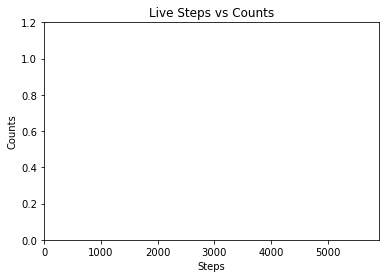

Buzzing and counting...:   3%|▎         | 2/60 [00:25<12:19, 12.75s/it]

Position now: 2638.761321 um


Buzzing and counting...:   5%|▌         | 3/60 [00:38<12:05, 12.74s/it]

Position now: 2642.0436600000003 um


Buzzing and counting...:   7%|▋         | 4/60 [00:50<11:53, 12.74s/it]

...

Position now: 2887.820549 um


Buzzing and counting...:  98%|█████████▊| 59/60 [12:31<00:12, 12.75s/it]

Position now: 2895.142016 um


Buzzing and counting...: 100%|██████████| 60/60 [12:44<00:00, 12.75s/it]

Position now: 2900.033736 um


In [51]:
stepVsCounts = np.zeros([len(steps), 3]) # Initialise data storage for N trials [# steps, position, counts]
stepVsCounts[:, 0] = steps

for i in tqdm(range(len(steps)), desc='Buzzing and counting...'):

    # Set SNSPD to 0 
    exhp.reset_detector(detectorOut, 0)

    # Move stage
    amc.move.setNSteps(axis=0, backward=False, step=stepSize)
    time.sleep(waitTime)

    # Start SNSPD and integrate
    exhp.reset_detector(detectorOut, bias, sleepTime=0.1)
    data, times = exhp.getHistDataWrapped(hist, intTime=intTime)

    positionAfter = amc.move.getPosition(axis)
    stepVsCounts[i,1] = positionAfter      

    counts = np.sum(data[0:numBins])
    stepVsCounts[i,2] = counts

    print(f'Position now: {positionAfter/1e3} um')

    # Live Plot
    

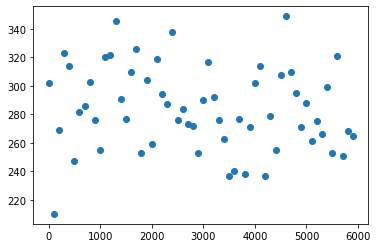

In [53]:
# Save data
steps = stepVsCounts[:, 0]
position = stepVsCounts[:, 1]
counts = stepVsCounts[:, 2]

plt.scatter(steps, counts)
plt.show()

# Inhomogeneous Lines

In [371]:
# SWEEP SETUP BY SITES, sorted from low -> high energy
# linesFreq = [195.34697, 195.42657, 196.08637, 197.52763] # From Alexey's paper
# wavelengths = [1534.583, 1533.938, 1528.813, 1517.641]
# linesLabel = ['a1', 'a2', 'a3', 'a7']

sweep = swp.timTam_config(
    run_id = 'SiC_inhomogeneous_run1',
    wavelengths = [min_wavelength, max_wavelength],
    # wavelengths = wavelengths,
    piezo_centre = 70,
    scan_half = 0,
    num_steps = 800,
    bias = -0.85,
    int_time = 4.5,
    laser_amplitude = 200,
)

print(fr"Set wavelengths: {wavelengths}")

Set wavelengths: [1535.         1534.99749361 1534.99498723 1534.99248085 1534.98997449
 1534.98746813 1534.98496178 1534.98245544 1534.97994911 1534.97744278
 1534.97493646 1534.97243015 1534.96992385 1534.96741756 1534.96491128
 1534.962405   1534.95989873 1534.95739247 1534.95488622 1534.95237998
 1534.94987375 1534.94736752 1534.9448613  1534.94235509 1534.93984889
 1534.93734269 1534.93483651 1534.93233033 1534.92982416 1534.927318
 1534.92481185 1534.9223057  1534.91979956 1534.91729344 1534.91478732
 1534.9122812  1534.9097751  1534.907269   1534.90476292 1534.90225684
 1534.89975076 1534.8972447  1534.89473865 1534.8922326  1534.88972656
 1534.88722053 1534.88471451 1534.88220849 1534.87970249 1534.87719649
 1534.8746905  1534.87218452 1534.86967855 1534.86717258 1534.86466663
 1534.86216068 1534.85965474 1534.8571488  1534.85464288 1534.85213696
 1534.84963106 1534.84712516 1534.84461927 1534.84211338 1534.83960751
 1534.83710164 1534.83459578 1534.83208993 1534.82958409 1534.

In [72]:
# COMPARE SET WAVELENGTHS TO CENTRE FREQUENCIES
lhzz.set_piezo_center(laserIP, 70)

for wave in wavelengths:
    lhzz.set_laser_wavelength(laserIP, wave)
    time.sleep(2)
    print(fr'Measured frequency: {exhp.get_laser_frequency(wm, 10)} THz')

Wavelength now set to 1534.583
Measured frequency: 195.33867492675782 THz
Wavelength now set to 1533.938
Measured frequency: 195.42823944091796 THz
Wavelength now set to 1528.813
Measured frequency: 196.0836380004883 THz
Wavelength now set to 1517.641
Measured frequency: 197.52926330566407 THz


Cycle time: 21.0 ms


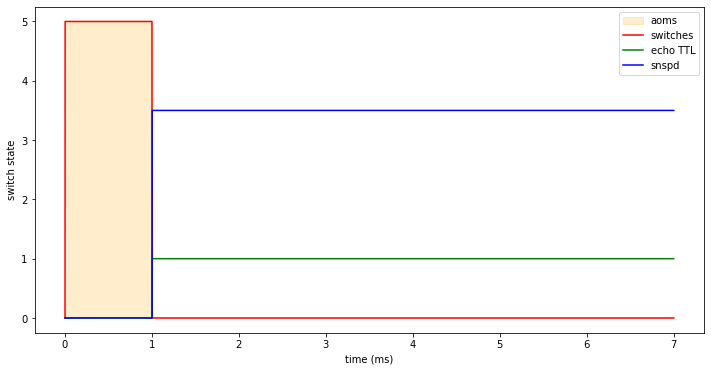

In [367]:
# SET UP AND APPLY SWITCHING PARAMETERS FOR SIC
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 6e3, # us
    dead_cycle = 2
)

print(f'Cycle time: {(switch.dead_cycle + 1) * (switch.exc_time + switch.count_time) / 1e3} ms')

swtch.PLE_switch_config.apply(switch, awg, test = False)

In [463]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 50e-6, # s
    n_bins = 600
)

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 
tt = TimeTagger.createTimeTagger()
binwidth = 20e-6 * ps  # s
n_bins = 600 # number of bins
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = binwidth, 
                             n_bins = n_bins)

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV

KeyboardInterrupt: 

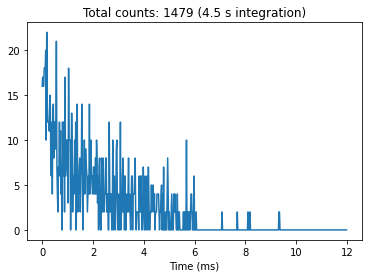

In [372]:
# TEST HISTOGRAM
exhp.reset_detector(detectorOut, 0)
time.sleep(0.1)
intTime = 4.5
exhp.reset_detector(detectorOut, -0.85)
counts, times = exhp.getHistDataWrapped(hist, intTime = intTime)
plt.plot(times*1e3, counts)
plt.xlabel('Time (ms)')
plt.title(fr'Total counts: {np.sum(counts)} ({intTime} s integration)')
plt.show()

In [374]:
# SAVE METADATA
exhp.PLE_data_collect(
    description = 'SiC_motor_run2',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 0.38, 
    attocube = amc,
    axis = 0,
)

,0
Description,SiC_motor_run2
Run ID,SiC_inhomogeneous_run1
Timestamp,2026-03-18_17-28-26
Excitation Time (ms),1.0
Count Time (ms),6.0
Dead Cycle,2
AOMs (GHz),0.38
Dead Time (ps),0.0
Integration Time (s),4.5
Bin Width (us),50.0


In [91]:
# INITIALISE + ID FOR DATA COLLECTION
sweepID = 1

datestring = time.strftime('%Y-%m-%d')
pathData  = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/{dateString}/sic'
pathPlots = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/plots/{dateString}/sic'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

### Motor + Piezo Scan

In [120]:
# MOTOR + PIEZO SCAN FOR FINE SCALE STRUCTURE
print(fr'Run {sweepID}')
lhzz.turn_laser_on(laserIP)

try:
    for wavelength in [wavelengths[-1]]:        
        # SET LASER POWER? #
        lhzz.set_piezo_center(laserIP, sweep.piezo_centre) # Set piezo to centre
        lhzz.set_laser_wavelength(laserIP, wavelength) # Change motor centre

        # try:
        #     # PID TO LINE CENTRE 
        #     ben.PIDtoSetpointToptica(timTam, wm, target = linesFreq[i],
        #                     N = 16, Kp = 7, Ki = 3, Kd = 4, dt = 0.2)
        #     print('PID success!')

        # except Exception as e:
        #     print('PID failed... continuing anyways..')
        #     continue

        # SET PVs BASED ON LINE CENTRE
        centrepV = lhzz.get_piezo_center(laserIP)
        pVs = np.linspace(-sweep.scan_half, 
                        sweep.scan_half, 
                        sweep.num_steps) + centrepV
        
        # SUBFOLDER FOR EACH WAVLENGTH
        subFolderData = os.path.join(pathData, f"{wavelength:.5f}")
        subFolderPlots = os.path.join(pathPlots, f"{wavelength:.5f}")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)

        for j, pV in tqdm(enumerate(pVs), total = len(pVs)):
            lhzz.set_piezo_center(laserIP, pV)
            print(f"Starting step {j+1}, pV = {pV}")
            time.sleep(3)
            try:
                freq = exhp.get_laser_frequency(wm, 10)       # [THz]
            except Exception as e:
                freq = 0
            exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 0.01)
            data, times = exhp.getHistDataWrapped(hist, intTime = intTime)      
            dataAndTime = np.array([times, data])

            # save data
            now = datetime.datetime.now()
            filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_pV_" + str(np.round(pV, 1)) + "_V"
            np.savetxt(os.path.join(subFolderData, filename + ".csv"), 
                       dataAndTime, delimiter = ",")
            
            # plot data
            fig, ax = plt.subplots()
            ax.plot(times*1e3, data)
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
            ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
            fig.savefig(os.path.join(subFolderPlots, filename + ".jpg"))
            # fig.savefig(os.path.join(subFolderPlots, filename + ".eps"))
            plt.close(fig)
            clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)

sweepID += 1

200it [44:33, 13.37s/it]


Laser is off


### Motor Scan

In [ ]:
motorID = 1

In [376]:
c = 299792458
min_wavelength = 1533e-9
max_wavelength = 1535e-9

max_freq = c/min_wavelength
min_freq = c/max_wavelength

frequencies = np.linspace(min_freq, max_freq, 800)
wavelengths = c/frequencies * 1e9

In [427]:
wavelengths

[1517.64, 1522.469, 1528.767]

In [377]:
# MOTOR SCAN FOR LARGE SCALE STRUCTURE
lhzz.turn_laser_on(laserIP)
print(fr'Run {motorID}')

# Savepath
datestring = time.strftime('%Y-%m-%d')
pathData  = f'data/' + datestring + f'/sic/'
pathPlots = f'plots/' + datestring + f'/sic/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok=True)
subFolderData = pathData + "/" + f"motor_run{motorID}" + "/" # don't forget ending "/"
subFolderPlots = pathPlots + "/" + f"motor_run{motorID}" + "/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Measurement Paranmeters
intTime = sweep.int_time
bias = sweep.bias

try:
    for wavelength in tqdm(wavelengths[::-1]):
        # Set up measurement parameters
        # lhzz.set_piezo_center(laserIP, 70)
        lhzz.set_laser_wavelength(laserIP, wavelength)
        exhp.reset_detector(detectorOut, bias, sleepTime = 0.1)
        time.sleep(0.1)

        # Start sweep
        freq = exhp.get_laser_frequency(wm, 10) # THz
        print(f"Measured Frequency: {freq} THz")
        data, times = getHistDataWrapped(hist, intTime = intTime)      
        dataAndTime = np.array([times, data])
        exhp.reset_detector(detectorOut, 0, sleepTime = 0.1)

        # Save data
        now = datetime.datetime.now()
        filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz"
        np.savetxt(subFolderData + filename + ".csv", dataAndTime, delimiter = ",")

        # Plot data
        fig, ax = plt.subplots()
        ax.plot(times*1e3, data)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel(f"Counts ({intTime} s integration)")
        ax.set_title(str(np.round(freq*1e3, 3)) +" GHz")
        fig.savefig(subFolderPlots + filename + ".jpg")
        plt.close(fig)

        clear_output()

finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    motorID += 1

100%|██████████| 800/800 [1:11:54<00:00,  5.39s/it]


Laser is off


# Rabis
Tim's code from flashy county.ipynb

In [298]:
def plot_county_rabi(subFolderData, echoCentre, echoLength):
    # other arguments: field, frequency, 
    # get dem files
    files = os.listdir(subFolderData)
    files = [file for file in files if '.csv' in file]

    # empty counts and pilengths
    counts = np.zeros(len(files))
    piLengths = np.zeros(len(files))

    # get counts and piLengths and now populate
    for i, file in enumerate(files):
        fileRead = np.loadtxt(subFolderData + file, delimiter=",")
        times, data = fileRead[0], fileRead[1]
        timeStart = (echoCentre-(0.5*echoLength)) * 1e-6
        timeEnd = (echoCentre + 0.5*echoLength) * 1e-6
        lastTime = times[-1]
        # counts[i] = np.sum(data[(times>timeStart) & (times<timeEnd)]) - np.sum(data[(times>timeEnd) & (times<(timeEnd + echoLength*1e-6))])

        echoCounts = np.sum(data[(times>timeStart) & (times<timeEnd)])
        backgroundTimeCorrection = (lastTime - timeEnd) / (timeEnd-timeStart)
        backgroundCounts = (np.sum(data[(times>timeEnd) & (times<lastTime)])) / backgroundTimeCorrection
        counts[i]  = echoCounts - backgroundCounts

        piLengths[i] = float(file.split("_")[1].split()[1])

    field = (files[0].split("_")[-1].split()[0])
    frequency = (files[0].split("_")[-2].split()[0])
    
    filename = "Rabi Oscillation Experiment, Frequency " + frequency + " THz, Field "+ field + " mT"
    fig, ax = plt.subplots(figsize = [6,4])
    ax.plot(piLengths,counts, '.', label= "Total Counts: " + str(sum(data)))
    ax.set_xlabel("Pi Pulse Length (us)")
    ax.set_ylabel("Photon Counts (number)")
    ax.set_title(filename)
    
    fig.savefig(pathPlots+filename+".jpg")

def set_up_3_pulse_echo(pi2, pi, tau, countFor = 10, switchPreDelay = 3, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  

    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, tau, pi2, countFor]
    aomTimings = [pi2, tau, pi, tau, pi2, countFor]
    ttlTimings = [pi2 + tau + pi + tau + pi2, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, tau + pi2 + countFor]
        aomTimings = [pi2 + tau, pi, tau+pi2 + countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau+pi2 + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2+ tau + pi + tau + pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                         color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                 c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                 c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                 c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

def set_up_2_pulse_echo(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  
    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, tau + pi2 + countFor]
    aomTimings = [pi2, tau, pi, tau + pi2 + countFor]
    ttlTimings = [pi2 + tau + pi + tau + pi2/2, countFor + pi2/2]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, tau + pi2 + countFor]
        aomTimings = [pi2 + tau, pi, tau + pi2 + countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau + pi2 + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2+ tau + pi + tau + pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                        color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

def set_up_1_pulse_echo(pi, tau, countFor, switchPreDelay, nPoints = 5000, plotting = False, verbose = False, piOff = False):  
    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi, tau + countFor]
    aomTimings = [pi, tau + countFor]
    ttlTimings = [pi + tau, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
            
    if piOff:
        switchTimings = [pi2, tau + pi + tau + pi2 + countFor]
        aomTimings = [pi2, tau + pi + tau + pi2 + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                        color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return period

In [315]:
# SET UP AND APPLY TIMETAGGER PARAMETERS
# tt_config = swtch.PLE_tt_config(
#     dead_time = 0.01e-9, # s
#     trigger_level = 0.042, # V
#     bin_width = 50e-6, # s
#     n_bins = 600
# )

# hist = swtch.PLE_tt_config.apply(tt_config) 

ps = 1e12 
tt = TimeTagger.createTimeTagger()
binwidth = 10e-6 * ps  # s
n_bins = 500 # number of bins
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = binwidth, 
                             n_bins = n_bins)

tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV

In [ ]:
rabiCounter = 1

dateString = time.strftime('%Y-%m-%d')
pathData  = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/data/{dateString}/sic'
pathPlots = fr'C:/Users/Mario/Documents/GitHub/longterm_sweeps/plots/{dateString}/sic'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

In [320]:
# Check run number and sweep points
# piLengths = swp.sweep_points(1, 2e3, 24)
piLengths = swp.sparse_sweep_pos(1, 100e3)
print(len(piLengths))
print(rabiCounter)

16
13


Pi Pulse Lengths - [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
2101.0
2102.0
2105.0
2110.0
2120.0
2150.0
2200.0
2300.0
2600.0
3100.0
4100.0
7100.0
12100.0


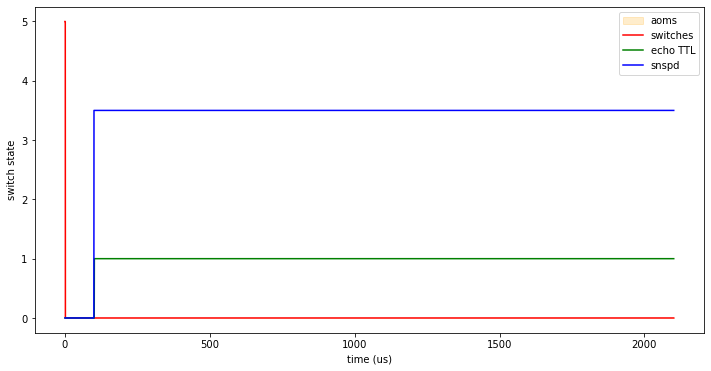

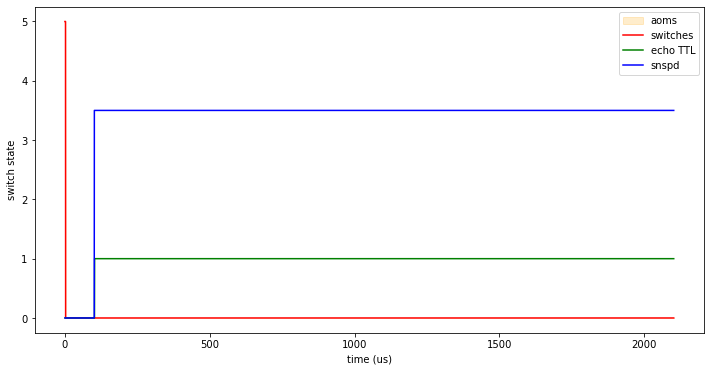

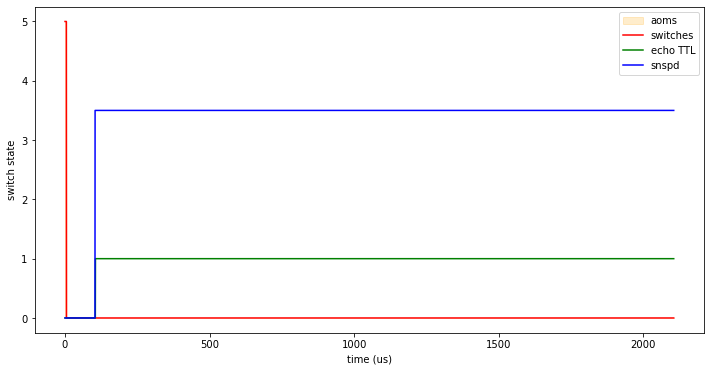

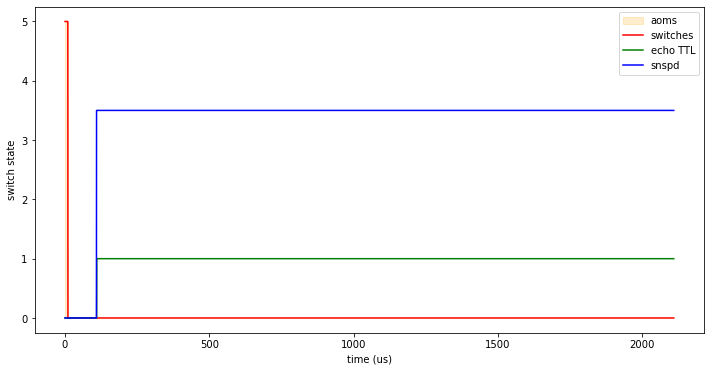

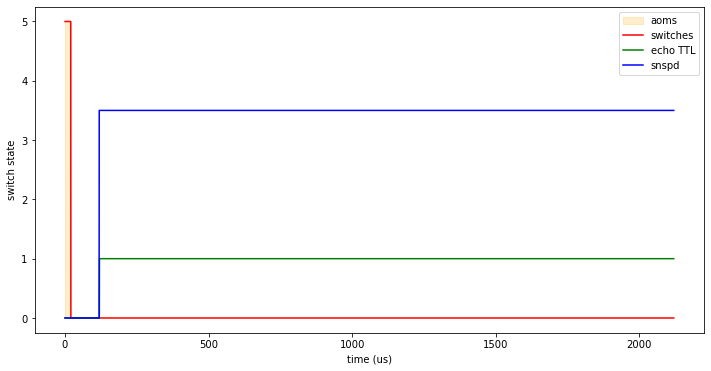

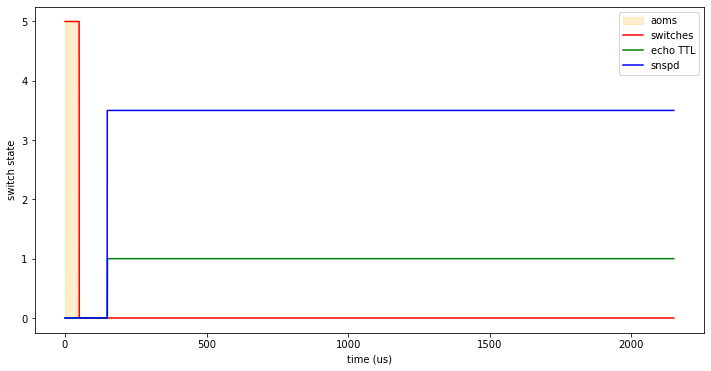

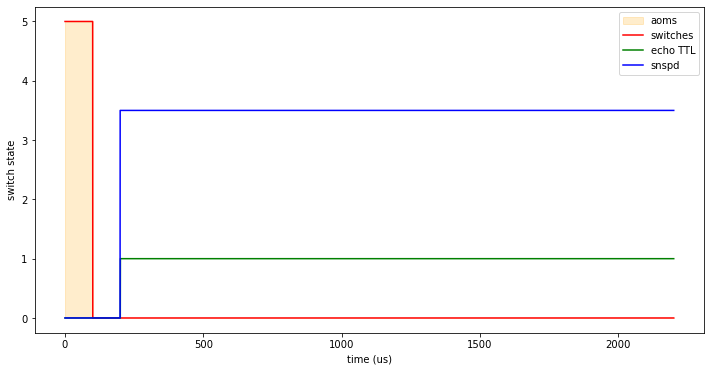

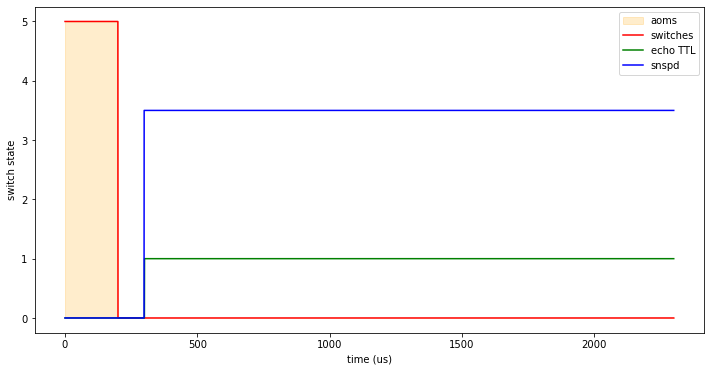

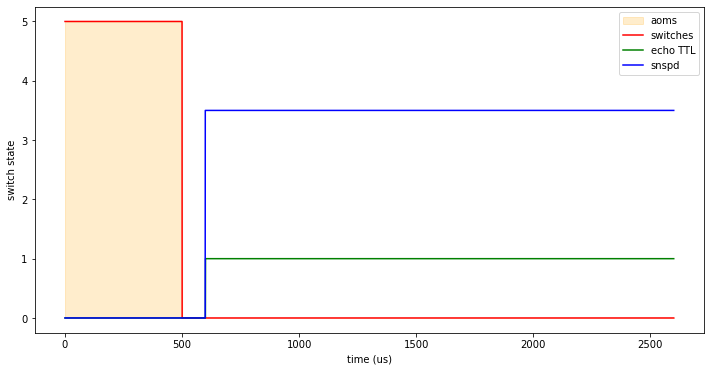

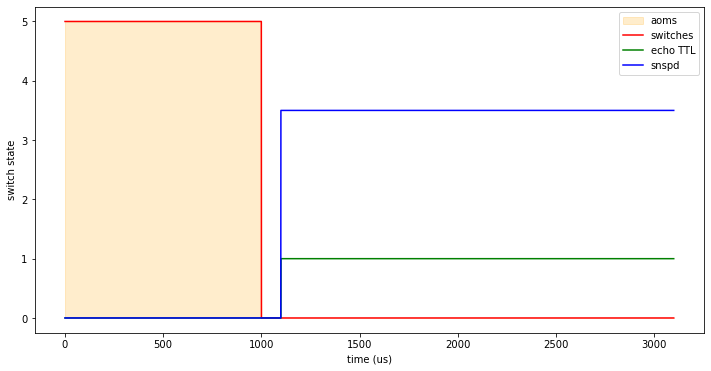

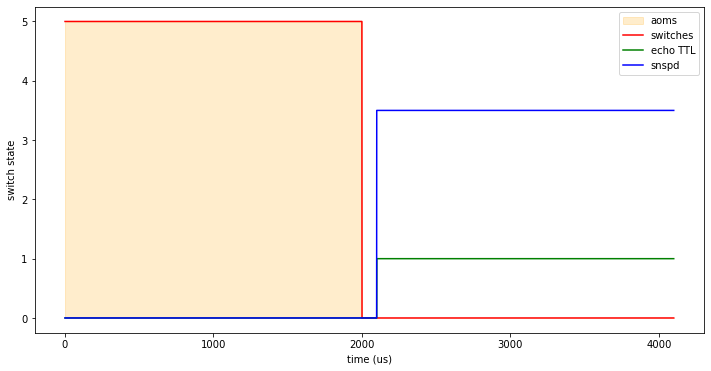

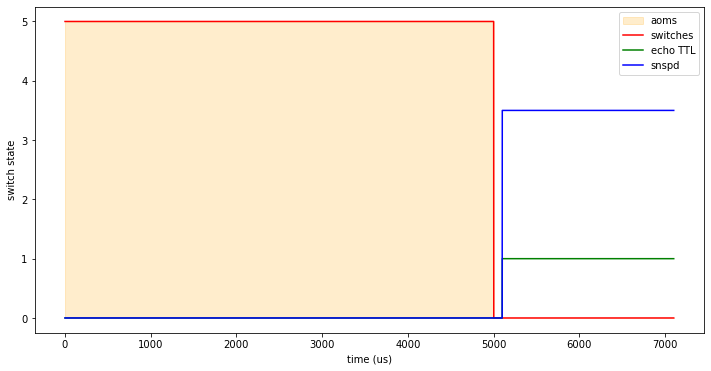

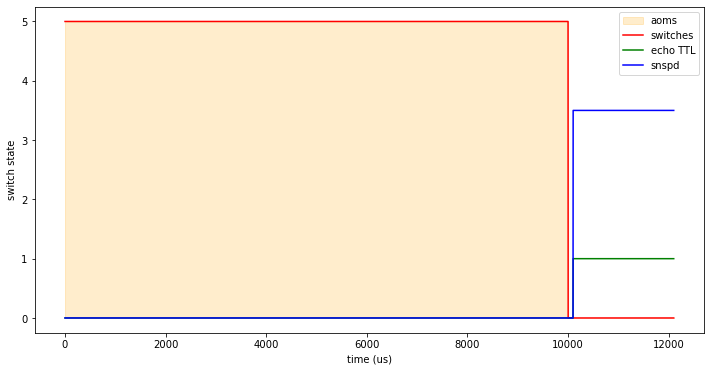

In [306]:
# Check pulse sequence
switchPreDelay = 1
countFor = binwidth*n_bins/1e6 # assuming us is correct
print ("Pi Pulse Lengths - " + str(piLengths))
tau = 100

for pi in piLengths:
    p = set_up_1_pulse_echo(pi, tau, 
                    countFor, switchPreDelay, nPoints = 5000, 
                    plotting = True)
    print(p)

In [ ]:
# DO THE SWEEP

# rememmber to turn laser on
lhzz.turn_laser_on(laserIP)
time.sleep(0.1)

# Make folders
site = np.round(lhzz.get_laser_wavelength(laserIP), 3)
subFolderData = pathData + "/fake rabi" + f"/{site} nm" + f"/run{rabiCounter}/"    # don't forget ending "/"
subFolderPlots = pathPlots + "/fake rabi" + f"/{site} nm" + f"/run{rabiCounter}/"
os.makedirs(subFolderData, exist_ok = True)
os.makedirs(subFolderPlots, exist_ok = True)

# Set Up variables
bias = -0.85
switchPreDelay = 10
countFor = binwidth*n_bins/1e6 # assuming us is correct
print ("Pi Pulse Lengths - " + str(piLengths))
pi2 = 1.8
tau = 12

# to ensure that we are growing our pi pulse in both directions
oldPiLength = piLengths[0]
currentTau = tau

# go over pilengths
try:
        for index, piLength in tqdm(enumerate(piLengths)):
                # # get field and angle
                # fld, angle = get_field_vector()
                # fld = 0
                # angle = 0

                # grab the wavemeter frequency:
                frequency = np.round(exhp.get_laser_frequency(wm, 10), 6)

                # configure switching
                # 1 pulse
                period = np.sum([tau, piLength, countFor])/1e6 # convert to s
                print(fr"Pulse period: {period*1e6}us")
                set_up_1_pulse_echo(piLength, tau, 
                                    countFor, switchPreDelay, nPoints = 5000, 
                                    plotting = False)
                # 2 pulse
                # currentTau -= (piLength - oldPiLength)/2 
                # period = np.sum([pi2, tau, piLength, currentTau + pi2 + countFor])
                # set_up_2_pulse_echo(pi2, pi = piLength, tau = currentTau, 
                #                     countFor = 100, switchPreDelay = 1, nPoints = 5000,
                #                     plotting = False)

                # 3 pulse
                # set_up_3_pulse_echo(pi2, pi = piLength, tau = currentTau, 
                #                     countFor = 100, switchPreDelay = 1, nPoints = 5000,
                #                     plotting = False)

                time.sleep(0.1)
                exhp.reset_detector(detectorOut, bias)
                time.sleep(0.1)

                # Save data and plots
                data, times = exhp.getHistDataWrapped(hist, intTime = period * 2e3) # 2e3 iterations
                print(fr"Integration time: {period * 2e3} s")
                time.sleep(0.1)
                exhp.reset_detector(detectorOut, 0)
                dataAndTime = np.array([times, data])
                now = datetime.datetime.now()
                timeNow = now.strftime("%Y-%m-%d %H-%M-%S")
                filename =  f"{timeNow}_{site}_nm_piPulse_{piLength:.3f}_us"
                np.savetxt(subFolderData + filename + ".csv", dataAndTime, delimiter = ",")
                fig, ax = plt.subplots()
                ax.plot(times*1e6, data, label = "Total Counts: " + str(sum(data)))
                ax.set_xlabel("Time (us)")
                ax.set_ylabel(f"Counts ({intTime} s integration)")
                ax.set_title(str(np.round(frequency, 6)) +" GHz")
                plt.legend()
                fig.savefig(subFolderPlots + filename + ".jpg")
                plt.close(fig)

                oldPiLength = piLength
                print(f"{index+1}/{len(piLengths)} Done @ {np.round(piLength,3)}")

finally:
        lhzz.turn_laser_off(laserIP)
        rabiCounter += 1

Laser is on
Pi Pulse Lengths - [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]


0it [00:00, ?it/s]

Pulse period: 5013.0us
Integration time: 10.026 s


1it [00:09,  9.72s/it]

1/16 Done @ 1
Pulse period: 5014.0us
Integration time: 10.028 s


...

14/16 Done @ 20000
Pulse period: 55012.0us
Integration time: 110.024 s


15it [03:55, 31.26s/it]

15/16 Done @ 50000
Pulse period: 105012.0us
Integration time: 210.024 s


16it [05:44, 21.56s/it]

16/16 Done @ 100000
Laser is off


# Magnet Ramp

Magnet Target Field Steps
Max Field = 60 T
Min Field = 0 T
Step Size = 1.2 T
Number of Steps = 52

Field Array: [ 0.   1.2  2.4  3.6  4.8  6.   7.2  8.4  9.6 10.8 12.  13.2 14.4 15.6
 16.8 18.  19.2 20.4 21.6 22.8 24.  25.2 26.4 27.6 28.8 30.  31.2 32.4
 33.6 34.8 36.  37.2 38.4 39.6 40.8 42.  43.2 44.4 45.6 46.8 48.  49.2
 50.4 51.6 52.8 54.  55.2 56.4 57.6 58.8 60.  61.2]

Reverse Field Array: [61.2 60.  58.8 57.6 56.4 55.2 54.  52.8 51.6 50.4 49.2 48.  46.8 45.6
 44.4 43.2 42.  40.8 39.6 38.4 37.2 36.  34.8 33.6 32.4 31.2 30.  28.8
 27.6 26.4 25.2 24.  22.8 21.6 20.4 19.2 18.  16.8 15.6 14.4 13.2 12.
 10.8  9.6  8.4  7.2  6.   4.8  3.6  2.4  1.2  0. ]
Cycle time: 15.0 ms


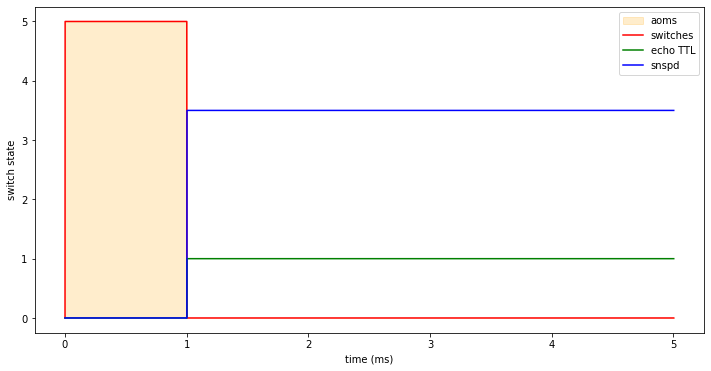

In [615]:
ps = 1e12

# SWEEP
sweep = swp.timTam_config(
    run_id = 'SiC_inhomogeneous_motor_zeeman_run3',
    wavelengths = wavelengths,
    piezo_centre = 70,
    scan_half = 0,
    num_steps = 30,
    bias = -0.85,
    int_time = 4,
    laser_amplitude = 290, # CHECK ON TIMTAM
)

# MAGNET
iz.current_limit(70)
iz.ramp_rate(0.3) 
iz.coil_constant(1) # mango uncalibrated - set cc = 1 
flds = ferg.define_target_fields(
    min_fld = 0, 
    max_fld = 60, 
    step = 50
)

# SWITCH
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 4e3, # us
    dead_cycle = 2
)
print(f'Cycle time: {(switch.dead_cycle + 1) * (switch.exc_time + switch.count_time) / 1e3} ms')
swtch.PLE_switch_config.apply(switch, awg, test = False)

# TIMETAGGER
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 20e-6 * ps, # s
    n_bins = 500
)
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width, 
                             n_bins = tt_config.n_bins
                             )
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV
# hist = swtch.PLE_tt_config.apply(tt_config) # this is the fast way but I don't think it's working properly

Laser is on


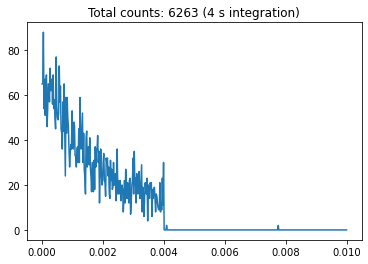

In [614]:
# TEST DETECTOR
lhzz.turn_laser_on(laserIP)
exhp.reset_detector(detectorOut, 0)
time.sleep(1)

# TEST HISTOGRAM
exhp.reset_detector(detectorOut, -0.85)
counts, bins = getHistDataWrapped(hist, intTime = sweep.int_time)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({sweep.int_time} s integration)')
plt.show()

In [ ]:
# SAVE METADATA
exhp.PLE_data_collect(
    description = f'SiC_zeeman_run{zeemanID}',
    sweep = sweep,
    switch = switch,
    tt = tt_config,
    aom_frequency = 0.38, 
    attocube = amc,
    axis = 0)

,0
Description,SiC_zeeman_run1
Run ID,SiC_inhomogeneous_zeeman_run1
Timestamp,2026-03-18_19-49-46
Excitation Time (ms),1.0
Count Time (ms),4.0
Dead Cycle,2
AOMs (GHz),0.38
Dead Time (ps),0.0
Integration Time (s),4.5
Bin Width (us),20000000000000.0


In [392]:
# RUN ID BLOCK ONCE
zeemanID = 1

In [454]:
# RAMP UP TO HIGH FIELD
magnet_data = []

for fld in flds:
    ferg.ramp_to_field(iz, fld)
    df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log")
    magnet_data.append(df)

##########RAMPING###########
RAMPING FIELD TO:  0.0  T
At 0.0 T. PSU State:
##########STATE check 1 ###########
State of <AMI430: z>:
Current limit:  20.0
Current Ramp limit:  3.6
Coil Constant:  1.0


Current:  -0.00267865
Calculated Supply current:  -0.002735765
Supply Voltage:  0.001871
Calculated System Resistance:  -0.7900007870545933
Calculated Field: -0.00176673


Saved Magnet Data to C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log\magnet_data_2026-03-25
##########RAMPING###########
RAMPING FIELD TO:  2.0  T
At 2.0 T. PSU State:
##########STATE check 1 ###########
State of <AMI430: z>:
Current limit:  20.0
Current Ramp limit:  3.6
Coil Constant:  1.0


Current:  1.98814761
Calculated Supply current:  1.988850109
Supply Voltage:  0.037292
Calculated System Resistance:  0.018724039617312126
Calculated Field: 1.992366434


Saved Magnet Data to C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log\magnet_data_2026-03-25
##########RAMPING###########


In [ ]:
# wavelengths = [1517.640, 1522.469, 1528.767]
# linesFreq = [197527, 196900, 196088]
wavelengths = [1517.640]
linesFreq = [197527] # GHz
linesLabel = 'SiC'

In [ ]:
# STANDARD PROCEDURE - RAMP, WAIT, THEN TAKE SPECTRUM
# SCAN FIELD AND SWEEP FREQUENCY
datestring = time.strftime('%Y-%m-%d')
pathData  = f'data/' + datestring + f'/confocal_field_ramp/run{zeemanID}/'
pathPlots = f'plots/' + datestring + f'/confocal_field_ramp/run{zeemanID}/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

print(fr'Run {zeemanID}')
lhzz.turn_laser_on(laserIP)

try:
    for i, fld in tqdm(enumerate(flds[:: -1]), total = len(flds)):
    # RAMP DOWN TO 0 FIELD
        try:
            ferg.ramp_to_field(iz, fld)
        except Exception as e:
            print(fr"Magnet ramp failed at {fld}T")
            break

        # WAIT AND LOG MAGNET DATA
        time.sleep(0.1)
        df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log")
            
        # SUBFOLDER FOR EACH FIELD
        subFolderData = os.path.join(pathData, f"{fld:.3f}A")
        subFolderPlots = os.path.join(pathPlots, f"{fld:.3f}A")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)
        
        for j, wave in enumerate(wavelengths):
            lhzz.set_laser_wavelength(laserIP, wave) # Change motor centre

            # SUBSUBFOLDER FOR EACH SITE
            subSubFolderData = os.path.join(subFolderData, f"{wave:.3f}")
            subSubFolderPlots = os.path.join(subFolderPlots, f"{wave:.3f}")
            os.makedirs(subSubFolderData, exist_ok = True)
            os.makedirs(subSubFolderPlots, exist_ok = True)

            # SET PIEZO CENTRE
            lhzz.set_piezo_center(laserIP, 70) # Set piezo to centre
            c = 299792458
            centreFreq = (c/(wave*1e-9))/1e9 # in GHz
            freqArray = np.linspace(centreFreq - 28, centreFreq + 28, 56)*1e9
            waveArray = c/freqArray

            # SWEEP MOTOR
            for k, wav in enumerate(waveArray):
                lhzz.set_laser_wavelength(laserIP, wav*1e9) # Change motor centre
                print(f"Starting step {k+1}")
                print(f"Current at {fld} A")
                exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 1)
                freq = exhp.get_laser_frequency(wm, 5) # THz
                data, times = exhp.getHistDataWrapped(hist, intTime = sweep.int_time)      
                dataAndTime = np.array([times, data])

                # SAVE DATA
                now = datetime.datetime.now()
                filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_"
                np.savetxt(os.path.join(subSubFolderData, filename + ".csv"), 
                        dataAndTime, delimiter = ",")

                # PLOT DATA
                fig, ax = plt.subplots()
                ax.plot(times*1e3, data)
                ax.set_xlabel("Time (ms)")
                ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
                ax.set_title(fr"{linesLabel} centred at {freq:.3f} THz")
                fig.savefig(os.path.join(subSubFolderPlots, filename + ".jpg"))
                plt.close(fig)
                clear_output(wait = True)

                exhp.reset_detector(detectorOut, 0)

# TURN LASER OFF, UNBIAS
finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    zeemanID += 1

100%|██████████| 52/52 [15:53:10<00:00, 1099.82s/it]


Laser is off


In [607]:
lhzz.set_piezo_center(laserIP, 70)
lhzz.set_laser_wavelength(laserIP, wavelengths[0])
time.sleep(5)
exhp.get_laser_frequency(wm, 10)

Wavelength already set to 1517.64


197.52651977539062

In [610]:
wavelengths

[1517.64]

In [624]:
current = iz.get_cs()    
print(current)  
print(f'{current:.8f}')  


-0.00011613
-0.00011613


In [626]:
# QUENCH PROCEDURE - RAMP SLOW WHILE TAKING SPECTRUM
# SCAN FIELD AND SWEEP FREQUENCY
datestring = time.strftime('%Y-%m-%d')
pathData  = f'data/' + datestring + f'/confocal_field_ramp/run{zeemanID}/'
pathPlots = f'plots/' + datestring + f'/confocal_field_ramp/run{zeemanID}/'
os.makedirs(pathData, exist_ok = True)
os.makedirs(pathPlots, exist_ok = True)

print(fr'Run {zeemanID}')
lhzz.turn_laser_on(laserIP)

try:
    while iz.is_quenched() is not True:
        df = ferg.AMI_data_collect(iz, save_path = r"C:\Users\Mario\Documents\GitHub\longterm_sweeps\data\experiment_log")
        current = iz.get_cs()        

        # SUBFOLDER FOR EACH FIELD
        subFolderData = os.path.join(pathData, f"{current:.8f}A")
        subFolderPlots = os.path.join(pathPlots, f"{current:.8f}A")
        os.makedirs(subFolderData, exist_ok = True)
        os.makedirs(subFolderPlots, exist_ok = True)
        
        for j, wave in enumerate(wavelengths):
            lhzz.set_laser_wavelength(laserIP, wave) # Change motor centre

            # SUBSUBFOLDER FOR EACH SITE
            subSubFolderData = os.path.join(subFolderData, f"{wave:.3f}")
            subSubFolderPlots = os.path.join(subFolderPlots, f"{wave:.3f}")
            os.makedirs(subSubFolderData, exist_ok = True)
            os.makedirs(subSubFolderPlots, exist_ok = True)

            # SET PIEZO CENTRE
            lhzz.set_piezo_center(laserIP, 70) # Set piezo to centre
            c = 299792458
            centreFreq = (c/(wave*1e-9))/1e9 # GHz
            freqArray = np.linspace(centreFreq - 50, centreFreq + 50, 30)*1e9 # Hz
            waveArray = c/freqArray

            # SWEEP MOTOR
            for k, wav in enumerate(waveArray):
                lhzz.set_laser_wavelength(laserIP, wav*1e9) # Change motor centre
                print(f"Starting step {k+1}")
                print(f"Current at {current} A")
                exhp.reset_detector(detectorOut, sweep.bias, sleepTime = 1)
                freq = exhp.get_laser_frequency(wm, 5) # THz
                data, times = exhp.getHistDataWrapped(hist, intTime = sweep.int_time)      
                dataAndTime = np.array([times, data])

                # SAVE DATA
                now = datetime.datetime.now()
                filename = now.strftime("%Y-%m-%d %H-%M-%S") + "_freq_" + str(np.round(freq*1e6)) +"_MHz_"
                np.savetxt(os.path.join(subSubFolderData, filename + ".csv"), 
                        dataAndTime, delimiter = ",")

                # PLOT DATA
                fig, ax = plt.subplots()
                ax.plot(times*1e3, data)
                ax.set_xlabel("Time (ms)")
                ax.set_ylabel(f"Counts ({sweep.int_time} s integration)")
                ax.set_title(fr"{linesLabel} centred at {freq:.3f} THz")
                fig.savefig(os.path.join(subSubFolderPlots, filename + ".jpg"))
                plt.close(fig)
                clear_output(wait = True)

                exhp.reset_detector(detectorOut, 0)

# TURN LASER OFF, UNBIAS
finally:
    exhp.reset_detector(detectorOut, 0)
    lhzz.turn_laser_off(laserIP)
    zeemanID += 1

Wavelength now set to 1517.7062335129763
Starting step 13
Current at -0.09475801 A
Laser is off


KeyError: "StatusError detected in string b'FREQ?'. Recieved: b'~~~~3False'"

# Test for Holeburning
Set fixed frequency
* Vary pulse sequence with 10*T1 excitation -> 3*T1 wait -> 1ms excitation -> collect
* Compare to 1ms excitation -> collect

Go to brighest line at high field

In [ ]:
# RAMP UP TO 16 A AND FIND STRONGEST LINE WITH TIMTAM ON TIMETAGGER. IF INCONCLUSIVE, CHOOSE ONE OF 3 SITES.
# MAGNET
iz.current_limit(20)
iz.ramp_rate(3) # fast ramp 
iz.coil_constant(1) # mango uncalibrated - set cc = 1 
flds = ferg.define_target_fields(
    min_fld = 0, 
    max_fld = 16, 
    step = 20
)

Cycle time: 21.0 ms


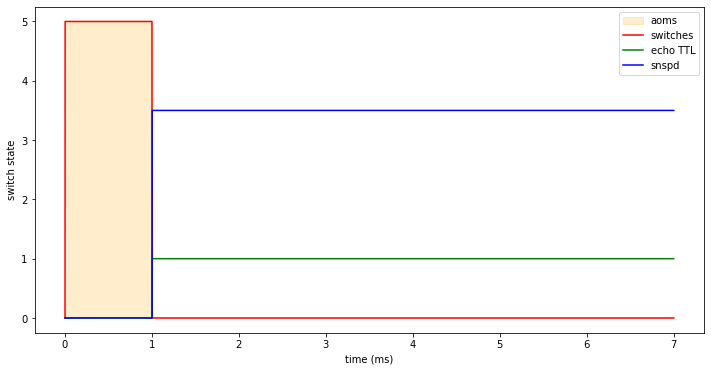

In [509]:
# ROUTINE: SINGLE PULSE
sweep.int_time = 10

# SWITCH
switch = swtch.PLE_switch_config(
    exc_time = 1e3, # us
    count_time = 6e3, # us
    dead_cycle = 2
)
A = (switch.dead_cycle + 1) * (switch.exc_time + switch.count_time) / 1e3
print(f'Cycle time: {A} ms')
swtch.PLE_switch_config.apply(switch, awg, test = False)

# TIMETAGGER
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 20e-6 * ps, # s
    n_bins = 500
)
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width, 
                             n_bins = tt_config.n_bins
                             )
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV
# hist = swtch.PLE_tt_config.apply(tt_config) # this is the fast way but I don't think it's working properly

Laser is on


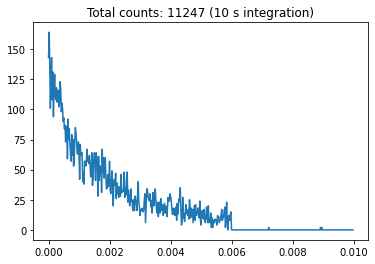

In [510]:
# TEST DETECTOR
lhzz.turn_laser_on(laserIP)
exhp.reset_detector(detectorOut, 0)
time.sleep(1)

# TEST HISTOGRAM
exhp.reset_detector(detectorOut, -0.85)
counts, bins = getHistDataWrapped(hist, intTime = sweep.int_time)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({sweep.int_time} s integration)')
plt.show()

In [466]:
def set_up_2_pulse_hole(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000, plotting = False, verbose = False, pi2Off = False, piOff = False):  
    '''
    ARGS:
    # pi2 - pi/2 pulse length
    # pi -
    # tau - remember HOW TAU IS DEFINED HERE
    # countFor - basically how long you want the SNSPD to count for. default to count for 10 us
    # switchPreDelay - moves the trigger back in time to account for switches taking a moment to ... switch. 
    #            be CAREFUL you might end up in the FID if you make this too long 
    # nPoints - the number of points - this defines the timing resolution with which we make the pulse sequence 
    '''

    # Easter egg - to make it so that the count time depends on pi pulse time
    if countFor == -1:
        countFor = 4*pi

    # Set up switch timings
    switchTimings = [pi2, tau, pi, countFor]
    aomTimings = [pi2, tau, pi, countFor]
    ttlTimings = [pi2 + tau + pi, countFor]
    totalTime = sum(switchTimings) # Verify all sequences are the same duration
    snspdTimings = [totalTime - (countFor + switchPreDelay), countFor + switchPreDelay]
    period = totalTime
    
    if pi2Off:
        switchTimings = [pi2 + tau, pi, countFor]
        aomTimings = [pi2 + tau, pi, countFor]
            
    if piOff:
        switchTimings = [pi2, tau + pi + countFor]
        aomTimings = [pi2, tau + pi + countFor]

    if pi2Off & piOff:
        switchTimings = [pi2+ tau + pi + countFor]
        aomTimings = [pi2+ tau + pi + countFor]

    if verbose == True:
        print('calculated timings')
    
    aoms = beeps.pulse_sequence(aomTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
    switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh=False, numPoints = nPoints, period = period)
    snspdBias = beeps.pulse_sequence(snspdTimings, highVoltage=3.5, startHigh=False, numPoints= nPoints, period = period)
    
    if piOff:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=True, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=True, highVoltage=5, numPoints = nPoints, period =period)

    if pi2Off:
        aoms = beeps.pulse_sequence(aomTimings,startHigh=False, highVoltage=5, numPoints = nPoints, period=period)
        switch1 = beeps.pulse_sequence(switchTimings, startHigh=False, highVoltage=5, numPoints = nPoints, period =period)

    if verbose == True:
        print('generated sequences')

    packet = [aoms , switch1, echoTTL,  snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        if verbose ==True:
            print('told awg')

    if plotting:
        plt.figure(figsize = (12, 6))
        plt.fill_between(aoms.times, aoms.lookupTable, 
                        color = 'orange', alpha = 0.2)
        plt.plot(switch1.times, switch1.lookupTable,
                c = 'red')
        plt.plot(echoTTL.times, echoTTL.lookupTable,
                c = 'green')
        plt.plot(snspdBias.times,snspdBias.lookupTable,
                c = 'blue')
        plt.legend(("aoms",
                    "switches", 
                    "echo TTL",
                    "snspd"))
        plt.xlabel('time (us)')
        plt.ylabel('switch state')
    return

def all_off(awg, snspd = False, plotting = True):  
    nPoints = 5000
    switchTimings = [100]
    aomTimings = [100]
    ttlTimings = [100]
    snspdTiming = [100]  

    switches = beeps.pulse_sequence(switchTimings, highVoltage = 5, startHigh = False, numPoints = nPoints)
    AOMs = beeps.pulse_sequence(aomTimings, highVoltage = 5, startHigh = False, numPoints = nPoints)
    echoTTL = beeps.pulse_sequence(ttlTimings, startHigh = False, numPoints = nPoints)
    snspdBias = beeps.pulse_sequence(snspdTiming, highVoltage = 3, startHigh = False, numPoints = nPoints)

    packet = [AOMs, switches, echoTTL, snspdBias]
    proChannels = [1,2,3,4]

    if not(plotting):
        proHelp.tell_awg(packet, proChannels, awg)
        for channel in proChannels:
            awg.disable_modulation(channel)

    if plotting:
        plt.plot(AOMs.times, AOMs.lookupTable, linewidth = 10)
        plt.plot(switches.times, switches.lookupTable, linewidth = 5)
        plt.plot(echoTTL.times, echoTTL.lookupTable)
        plt.plot(snspdBias.times,snspdBias.lookupTable)
        plt.legend(("AOMs",
                    "switches", 
                    # "switch 2", 
                    # "VOA", 
                    "echo TTL",
                    "snspd"))
    return

Cycle time: 111.0 ms


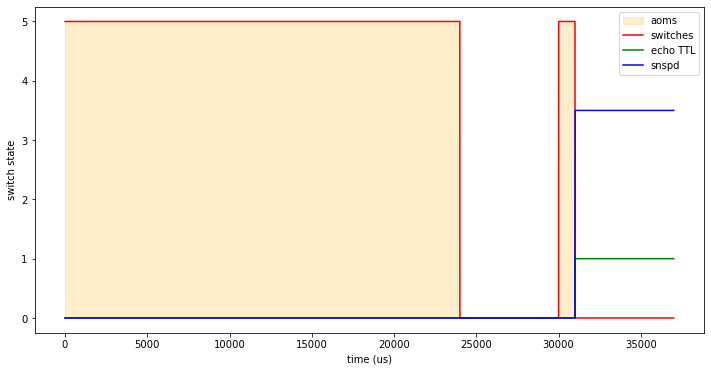

In [577]:
# PUMP, WAIT, EXCITE: TWO PULSE
# SWITCH
num_T1 = 12
T1 = 2e3 # us
pump = T1 * num_T1
wait = T1 * 3
excite = 1e3 # us
countFor = 6e3 # us
switchPreDelay = 2
set_up_2_pulse_hole(pump, excite, wait, countFor, 
                    switchPreDelay, nPoints = 5000, plotting = True)
set_up_2_pulse_hole(pump, excite, wait, countFor, 
                    switchPreDelay, nPoints = 5000, plotting = False)
swtch.set_deadcycles(awg, 2, channels = [1, 2])
B = ((pump + wait + excite + countFor)*3)/1e6
print(f'Cycle time: {B*1e3} ms')

# TIMETAGGER
tt_config = swtch.PLE_tt_config(
    dead_time = 0.01e-9, # s
    trigger_level = 0.042, # V
    bin_width = 20e-6 * ps, # s
    n_bins = 500
)
tt = TimeTagger.createTimeTagger()
hist = TimeTagger.Histogram(tagger = tt,
                             start_channel = 2, 
                             click_channel = 1, 
                             binwidth = tt_config.bin_width, 
                             n_bins = tt_config.n_bins
                             )
tt.setTriggerLevel(2, 0.25) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setDeadtime(2, 0.01e-9 * ps) # starts channel trigger level = 250 mV (signal is 500 mV)
tt.setTriggerLevel(1, 0.042) # click channel trigger level = 42 mV
# hist = swtch.PLE_tt_config.apply(tt_config) # this is the fast way but I don't think it's working properly

In [581]:
all_off(awg, plotting = False)

Number of T1 on pump: 12
Laser is on


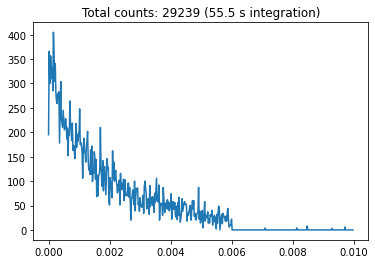

In [578]:
print(f'Number of T1 on pump: {num_T1}')

# TEST DETECTOR
lhzz.turn_laser_on(laserIP)
exhp.reset_detector(detectorOut, 0)
time.sleep(1)

# TEST HISTOGRAM
exhp.reset_detector(detectorOut, -0.85)
counts, bins = getHistDataWrapped(hist, intTime = B*500)
plt.plot(bins, counts)
plt.title(fr'Total counts: {np.sum(counts)} ({B*500} s integration)')
plt.show()

# Pulsing Sequence

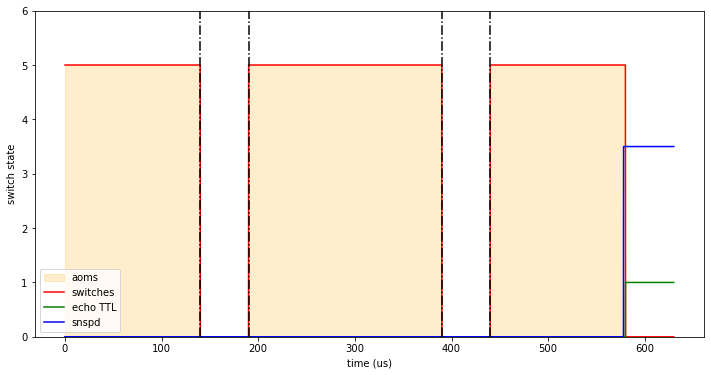

In [276]:
pi2 = 140
tau = 50
pi = 200
countFor = 50
switchPreDelay = 2

# tau is defined wrt. start of each pulse
set_up_3_pulse_echo(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000, 
                    plotting = True, verbose = False, pi2Off = False, piOff = False)

plt.vlines([pi2, pi2 + tau, pi2 + tau + pi, pi2 + tau + pi + tau], 0, 6, 
linestyles = '-.', colors = 'k')
plt.ylim([0, 6])
plt.show()

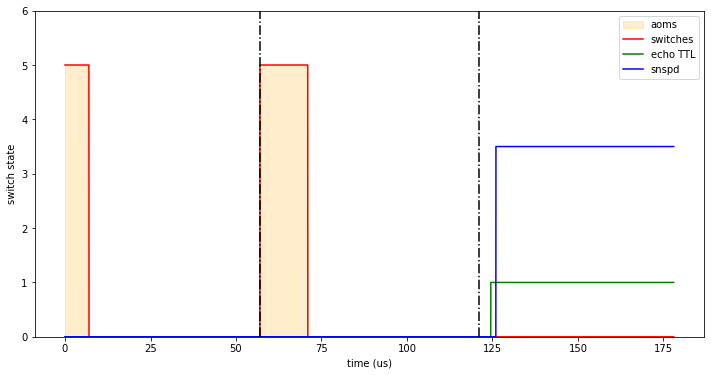

In [ ]:
pi2 = 7
tau = 50
pi = 14
countFor = 50
switchPreDelay = 2

set_up_2_pulse_echo(pi2, pi, tau, countFor, switchPreDelay, nPoints = 5000,
        plotting = True)

plt.vlines([pi2 + tau, pi2 + tau + pi + tau], 0, 6, 
linestyles = '-.', colors = 'k')
plt.ylim([0, 6])
plt.show()

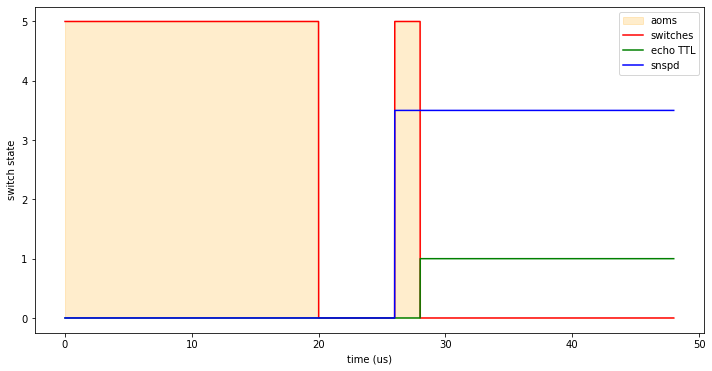

In [436]:
T1 = 2
pump = T1 * 10
wait = T1 * 3
excite = T1
countFor = 20
switchPreDelay = 2

set_up_2_pulse_hole(pump, excite, wait, countFor, 
                    switchPreDelay, nPoints = 5000, plotting = True)
plt.show()

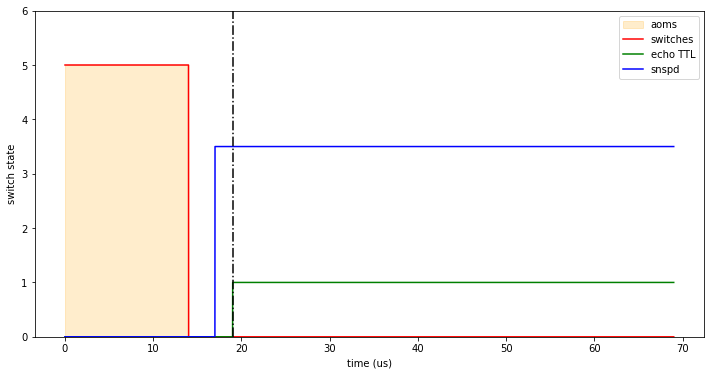

In [275]:
pi2 = 7
tau = 5
pi = 14
countFor = 50
switchPreDelay = 2

set_up_1_pulse_echo(pi, tau, countFor, switchPreDelay, nPoints = 5000,
        plotting = True)

plt.vlines([pi + tau], 0, 6, 
linestyles = '-.', colors = 'k')
plt.ylim([0, 6])
plt.show()